# Vodafone Music Subscription Prediction

## Sprint 1 - Initial Data Exploration

Goal of this notebook:

Perform initial data exploration and analyze target distribution.


### 1. Business Problem

We predict whether a subscriber will purchase the Music service.

Target variable:
- 1 - subscribed
- 0 - not subscribed

Business impact:
- False Negative → lose potential paying customer
- False Positive → marketing budget waste

### 2. Data Loading

Load dataset and check its basic structure.

In [1]:
# Installing the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# Downloading the dataset
DATA_PATH = '../data/raw/music.csv'
df = pd.read_csv(DATA_PATH)

### 3. Initial Data Inspection

We inspect:
- first rows
- dataset shape
- feature types

In [3]:
# Output the first 5 rows of the dataset
display(df.head())

# Print the dimension of a dataset
print(df.shape)

# Print dataset's data types
print(df.info())

,id,target,device_type,manufacturer_category,os_category,sim_count,tp_flag,lt,block_flag,days_exp,...,service_5_count_m3,service_6_count_m3,service_7_cost_m3,service_7_flag_m3,service_8_count_m3,income_brnd_cont_m3,data_type_1_m3,data_type_2_m3,data_type_3_m3,service_9_flag_m3
0,48104912810,0,7,1514,3,1.0,0,0.496508,0,299.0,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,13762.315646,1292.468784,NaN
1,4851497268,0,4,896,28,1.0,0,0.881540,0,189.0,...,11.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.000053,NaN
2,4877823097,0,7,592,3,2.0,0,0.811192,0,347.0,...,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.000977,NaN
3,4830183791,0,7,1756,3,2.0,0,0.928449,1,343.0,...,66.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.006680,NaN
4,48103940036,0,4,1057,28,1.0,0,0.578654,0,355.0,...,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.002487,1.0


(70000, 461)
<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Columns: 461 entries, id to service_9_flag_m3
dtypes: float64(452), int64(9)
memory usage: 246.2 MB
None


#### Dataset Overview

The dataset contains:

- 70,000 observations
- 461 features
- 9 integer features
- 452 float features

Memory usage: ~246.2 MB

The dataset is high-dimensional and primarily numerical,
which may increase model complexity and require careful feature selection.

### 4. Missing Values

In [4]:
# Calculating the mean number of missing values in columns
missing = df.isna().mean().sort_values(ascending=False)
print(missing.head(10))

# Displaying the number of columns in which the percentage of missing values exceeds 50%
print((missing > 0.5).sum())

count_url_category_13    0.992771
count_url_category_15    0.987029
vol_app_3                0.986643
count_app_3              0.986643
count_url_category_12    0.983129
vol_app_11               0.977329
count_app_11             0.977329
count_app_13             0.973143
vol_app_13               0.973143
count_url_category_1     0.972186
dtype: float64
62


#### Observations

Several features contain extremely high missing ratios (above 95%).

For example:
- count_url_category_13 → 99.3% missing
- vol_app_3 → 98.6% missing

Out of 461 total features, 62 columns (≈13%) contain more than 50% missing values.
This indicates a significant sparsity issue in the dataset.

#### Implication

After reviewing the feature dictionary, it was identified that many highly sparse 
features represent behavioral activity counts (e.g., count_*, vol_*).

In such cases, missing values likely indicate absence of activity rather than missing data.
Therefore, these features will not be removed automatically and will be treated carefully
during the cleaning stage.


### 5. Target Distribution

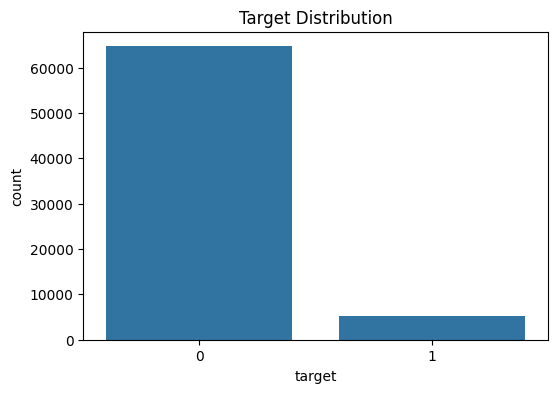

target
0    0.924271
1    0.075729
Name: proportion, dtype: float64
target
0    64699
1     5301
Name: count, dtype: int64


In [5]:
# Construction of a distribution graph of the target variable
plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df)
plt.title("Target Distribution")
plt.show()

# Calculation of the percentage ratio of subscribed customers (1) to unsubscribed customers (0)
print(df['target'].value_counts(normalize=True))

# Displaying the number of subscribed customers (1) and unsubscribed customers (0)
print(df['target'].value_counts())

#### Observations

The dataset is highly imbalanced.

- Class 0 (no subscription) represents 92.43% of the data.
- Class 1 (subscription) represents only 7.57%.

This indicates a strong class imbalance.

#### Implications

Accuracy will not be a reliable metric, as a naive model predicting only class 0 would achieve over 92% accuracy.

Therefore, evaluation metrics such as ROC-AUC, F1-score, and Recall will be more appropriate for this task.

Class imbalance handling techniques may be required during modeling.


### 6. Correlation Analysis

Top positive factors:
content_count_m1     0.116450
vol_app_11           0.112219
content_count_m3     0.111245
count_app_11         0.103440
content_count_m2     0.094392
count_gift_type_3    0.081626
count_app_5          0.076582
count_act_type_6     0.073582
rr_gift_type_3       0.062174
paym_count_m1        0.059475
Name: target, dtype: float64

Top negative factors:
is_obl_center        -0.045522
service_1_count      -0.046068
service_P_flag_m1    -0.058425
count_act_type_1     -0.062009
count_gift_type_1    -0.063975
count_sms_source_5   -0.066107
count_act_type_7     -0.066916
service_P_flag_m2    -0.080735
service_P_flag_m3    -0.099962
lt                   -0.186401
Name: target, dtype: float64


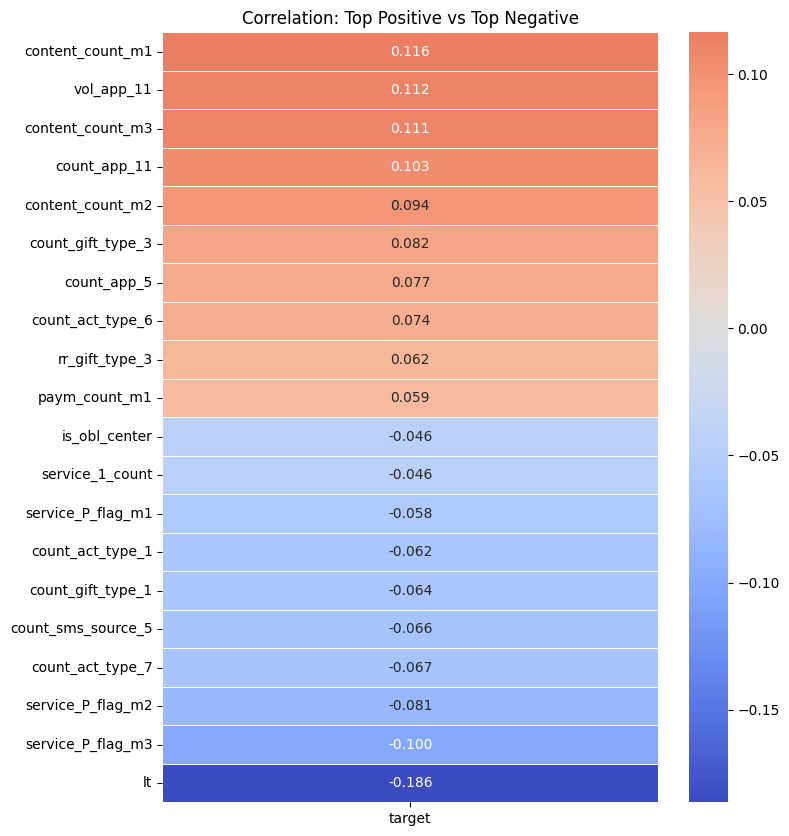

In [6]:
# Deleting ID (just the number)
df_clean = df.drop(columns=['id'])

# Calculating correlation with target
corr = df_clean.corr()['target'].sort_values(ascending=False)

# Removing empty values (NaN)
corr = corr.dropna()

# Top 10 positives (we skip the first one because it is the target itself = 1.0)
top_positive = corr[1:11]

# Top 10 negative (last 10 values)
top_negative = corr[-10:]

# Displaying correlation results
print("Top positive factors:")
print(top_positive)
print("\nTop negative factors:")
print(top_negative)

# Combining variables for a graph
top_features = pd.concat([top_positive, top_negative])
corr_matrix_to_plot = top_features.to_frame(name='target')

# Building a graph
plt.figure(figsize=(8, 10))
sns.heatmap(
    corr_matrix_to_plot,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt=".3f",             # 3 decimal places for accuracy
    linewidths=0.5
)
plt.title("Correlation: Top Positive vs Top Negative")
plt.show()

#### Correlation Analysis: Business Interpretation

Overall, the observed correlations are relatively weak (max |corr| ≈ 0.19). Subscription decisions are
likely influenced by multiple interacting factors rather than a single variable.

---

#### Top Positive Correlations

The strongest positive correlations are associated with:

- content_count_m1 / content_count_m2 / content_count_m3  
- vol_app_11  
- count_app_11  
- paym_count_m1  

These features appear to reflect **recent user activity and content consumption behavior**.

This suggests that users who are more active in consuming digital content,
using applications, or making payments are slightly more likely to subscribe
to the Music service.

Business hypothesis:
Higher engagement level → higher probability of subscription.

---

#### Top Negative Correlations

The strongest negative correlation is observed for:

- lt (-0.186)

`lt` represents customer lifetime or tenure,
this suggests that longer-tenure customers are less likely to subscribe.

Business hypothesis:
Newer users may be more open to adopting additional services,
while long-term users may already have established usage patterns.

Other negatively correlated features:

- service_P_flag_m2 / service_P_flag_m3  
- count_act_type_*  
- count_sms_source_5  

These may indicate that certain service users or activity types
are associated with lower likelihood of subscription.

---

#### Interpretation

Since all correlations are relatively small in magnitude,
the relationship between features and subscription is likely non-linear.

This suggests that tree-based models (Random Forest, Gradient Boosting)
may capture patterns better than purely linear approaches.

## Limitations & Next Steps

- Most individual features show weak linear correlation with the target.
- Correlation does not imply causation.
- Non-linear relationships may exist.

Next steps:
- Data cleaning
- Handling missing values based on feature semantics
- Preprocessing
- Model training and evaluation